# Pairs trading on the day lake — VI. The second way a Kalman backtest flatters itself

## `pairs_trading_19_kalman_pnl_accounting_day_lake.ipynb`

## 0. Why

This repository has already documented one way a Kalman-filtered pairs backtest inflates itself:
`pairs/models/kalman.py`'s `mode="smooth"` conditions every state on the whole sample, including bars
after it, and notebooks 01–03 traded on it. The fix (default `mode="filter"`, the causal one-step-ahead
recursion) dropped notebooks 01–03's headline Sharpe from `2.45` to something defensible — a look-ahead
in *information*.

This notebook is about a second, unrelated way, present even with a perfectly causal filter: a look-ahead
in *accounting*. A textbook backtest for a time-varying hedge books P&L as the change in the spread level,
`signal * diff(spread)`. When the hedge weights are fixed that is exactly what a trader earns. When the
weights move — a rolling-LS beta, a Kalman gain — it is not: part of that diff is the position's return,
and part of it is the filter re-marking its own parameters against today's price, which nobody holding
yesterday's position could have captured. Palomar (2025) ch. 15's own R code is not a strawman; it is a
careful, causal, well-documented implementation of exactly this backtest, which makes it the right worked
example. The point made here is general — it applies to any time-varying-hedge spread backtest, not to
this one book.

## 1. Setup

In [1]:
from pathlib import Path
import sys, warnings

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize_scalar

import pairs
from pairs import estimate_halflife
from pairs.strategies.spread_accounting import decompose_spread_pnl, turnover_and_fees
from pairs.models.kalman import _kalman_dynamic_hedge, filter_kf_on_new
from pairs.strategies.signals import generate_pair_signals
from pairs.strategies.evaluate import evaluate_pair_signals

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 100})
print("pairs", pairs.__version__)

CACHE = Path("cache")
bars = pd.read_parquet(CACHE / "day_market_bars.parquet", columns=["close", "dividend"])
px  = bars["close"].unstack("ticker")
div = bars["dividend"].unstack("ticker").reindex_like(px).fillna(0.0)
ret = (px + div) / px.shift(1) - 1.0

cost_tbl = pd.read_parquet(CACHE / "xs_cost_by_ticker_year.parquet")
cost_tbl = cost_tbl[cost_tbl["err"].eq("")]

LO, HI, T_TRN = "2013-01-01", "2022-12-31", 504

def logtr(ticker, lo=LO, hi=HI):
    # book's "log adjusted prices": total-return log price, level_0 = raw close on day 1.
    # ret[ticker] is built on the FULL lake, so its first in-window value is a return computed
    # against the pre-window close; zero it so cumprod() starts from close_lo exactly rather than
    # close_lo * (1 + that pre-window return).
    r = ret[ticker].loc[lo:hi].fillna(0.0).copy()
    r.iloc[0] = 0.0
    return np.log(px[ticker].loc[lo:hi].iloc[0] * (1.0 + r).cumprod())

for t in ["EWA", "EWC", "KO", "PEP", "SPY", "IVV", "VOO"]:
    s = px[t].loc[LO:HI].dropna()
    print(f"{t}: {len(s):,} sessions, {s.index[0].date()} -> {s.index[-1].date()}")

pairs 0.1.0


EWA: 2,518 sessions, 2013-01-02 -> 2022-12-30
EWC: 2,518 sessions, 2013-01-02 -> 2022-12-30
KO: 2,518 sessions, 2013-01-02 -> 2022-12-30
PEP: 2,518 sessions, 2013-01-02 -> 2022-12-30
SPY: 2,518 sessions, 2013-01-02 -> 2022-12-30
IVV: 2,518 sessions, 2013-01-02 -> 2022-12-30
VOO: 2,518 sessions, 2013-01-02 -> 2022-12-30


## 2. The identity

For a spread built from time-varying weights, write the weight vector at bar $t$ as $w_t$, the leg prices
as $y_t$, and a centering term $c_t$ (e.g. a Kalman intercept). The spread and its usual "book" P&L are

$$\text{spread}_t = w_t^\top y_t - c_t, \qquad \text{book}_t = \text{signal}_{t-1}\,(\text{spread}_t - \text{spread}_{t-1}).$$

Add and subtract $w_{t-1}^\top y_t$ inside the diff and it splits cleanly in two:

$$\text{spread}_t - \text{spread}_{t-1}
= \underbrace{w_{t-1}^\top (y_t - y_{t-1})}_{\text{tradable}}
+ \underbrace{(w_t - w_{t-1})^\top y_t - (c_t - c_{t-1})}_{\text{revaluation}}.$$

The **tradable** term is the return of holding the position formed at the close of $t-1$, with the weights
known at $t-1$, through the price move from $t-1$ to $t$ — it uses only information available when the
position was formed, and it is what a trader actually collects. The **revaluation** term multiplies
*today's* price level, $y_t$, by *how much the weights moved* between $t-1$ and $t$; both $w_t$ and $c_t$
are only known at the close of $t$, after that price move has already happened, so nobody could have
traded on it.

**Why it is one-sided under a contrarian rule.** A Kalman or rolling-LS update at $t$ moves $w_t$ in
proportion to the innovation observed at $t-1$ — which is itself proportional to how far the spread had
drifted from the filter's belief, i.e. to $\text{spread}_{t-1}$ itself. A contrarian signal is *also* a
function of $\text{spread}_{t-1}$, built to be long when the spread is low and short when it is high. Both
the weight *change* and the *signal* are driven by the same lagged spread, so their product does not
average to zero the way an unrelated noise term would: the sign of the revaluation term lines up with the
sign of the position that is betting the spread will move back, and it is positive in expectation.

A two-line illustration makes the bookkeeping concrete before touching real data.

In [2]:
# Two-line illustration: a spread with weights that step once, traded contrarian.
y_demo = np.array([[1.00, 1.00], [1.02, 1.01], [1.01, 1.03], [0.99, 1.02], [1.03, 1.00], [1.00, 1.01]])
w_demo = np.array([[1.0, -1.0]] * 3 + [[1.0, -1.3]] * 3)          # the hedge steps down once, at t=3
c_demo = np.zeros(6)
signal_demo = np.array([0.0, 1.0, 1.0, 1.0, -1.0, -1.0])           # long, then flips short (contrarian)

out_demo = decompose_spread_pnl(y_demo, w_demo, c_demo, signal_demo)
print("spread:     ", np.round(out_demo["spread"], 4))
print("book:       ", np.round(out_demo["book"], 4))
print("tradable:   ", np.round(out_demo["tradable"], 4))
print("revaluation:", np.round(out_demo["revaluation"], 4))
print("identity holds:", np.allclose(out_demo["book"], out_demo["tradable"] + out_demo["revaluation"]))
print("book == tradable + revaluation, and the whole jump at t=3 (the weight step) lands in revaluation:",
      np.isclose(out_demo["revaluation"][3], signal_demo[2] * ((w_demo[3] - w_demo[2]) @ y_demo[3])))

spread:      [ 0.     0.01  -0.02  -0.336 -0.27  -0.313]
book:        [ 0.     0.    -0.03  -0.316  0.066  0.043]
tradable:    [ 0.     0.    -0.03  -0.01   0.066  0.043]
revaluation: [ 0.     0.     0.    -0.306  0.     0.   ]
identity holds: True
book == tradable + revaluation, and the whole jump at t=3 (the weight step) lands in revaluation: True


## 3. Replicating the book's experiment

In [3]:
# The book's engine (ch. 15 R code, blocks [16], [20], [24]-[29]), translated line for line.

def rolling_ls(y1, y2, lookback=T_TRN, every=1):
    # fit_rollingLS: every-day refit, lookback-session window, forward-filled to the first fit
    n = len(y1)
    mu = np.full(n, np.nan); gamma = np.full(n, np.nan)
    for t in range(lookback - 1, n, every):
        a, b = y2[t - lookback + 1:t + 1], y1[t - lookback + 1:t + 1]
        X = np.column_stack([np.ones(lookback), a])
        coef = np.linalg.lstsq(X, b, rcond=None)[0]
        mu[t], gamma[t] = coef[0], coef[1]
    mu = pd.Series(mu).ffill().bfill().to_numpy()
    gamma = pd.Series(gamma).ffill().bfill().to_numpy()
    return mu, gamma

def kalman(y1, y2, T_trn=T_TRN, alpha=1e-5, momentum=False, alpha_speed=1e-6):
    # MARSS spec (block [24]/[27]): Z_t=[1,y2_t(,0)], A=0, R=var_eps, B=I (or momentum B), U=0,
    # Q=diag(alpha*var_eps, alpha*var_eps/var_y2 (, alpha_speed*var_eps/var_y2)),
    # x0=(mu_hat,gamma_hat(,0)), V0=diag(var_eps/T,var_eps/var_y2/T) (momentum: 0).
    # Returns the ONE-STEP-AHEAD predicted state x_{t|t-1} (MARSS xtt1, tinitx=0) -- causal.
    yc1 = y1[:T_trn] - y1[:T_trn].mean(); yc2 = y2[:T_trn] - y2[:T_trn].mean()
    g_hat = float(yc2 @ yc1 / (yc2 @ yc2))
    m_hat = float((y1[:T_trn] - g_hat * y2[:T_trn]).mean())
    eps = y1[:T_trn] - m_hat - g_hat * y2[:T_trn]
    var_eps = float(eps.var(ddof=1)); var_y2 = float(y2[:T_trn].var(ddof=1))
    if not momentum:
        x = np.array([m_hat, g_hat])
        P = np.diag([var_eps / T_trn, var_eps / var_y2 / T_trn])
        B = np.eye(2)
        Q = np.diag(alpha * np.array([var_eps, var_eps / var_y2]))
        Zf = lambda t: np.array([1.0, y2[t]])
    else:
        x = np.array([m_hat, g_hat, 0.0])
        P = np.zeros((3, 3))
        B = np.array([[1, 0, 0], [0, 1, 1], [0, 0, 1]], dtype=float)
        Q = np.diag([alpha * var_eps, alpha * var_eps / var_y2, alpha_speed * var_eps / var_y2])
        Zf = lambda t: np.array([1.0, y2[t], 0.0])
    R = var_eps
    xp = np.zeros((len(y1), len(x)))
    x, P = B @ x, B @ P @ B.T + Q
    for t in range(len(y1)):
        xp[t] = x
        Z = Zf(t)
        S = Z @ P @ Z + R
        K = P @ Z / S
        v = y1[t] - Z @ x
        x = x + K * v
        P = P - np.outer(K, Z @ P)
        x, P = B @ x, B @ P @ B.T + Q
    return xp[:, 0], xp[:, 1]

def bb_threshold_signal(spread, entry=1.0, exit_=0.0, lookback=6 * 21, start=T_TRN):
    # generate_BB_thresholded_signal (block [15]): population-sd Bollinger z-score, entry 1, exit 0
    s = pd.Series(spread)
    z = ((s - s.rolling(lookback).mean()) / s.rolling(lookback).std(ddof=0)).to_numpy()
    sig = np.zeros(len(spread))
    for t in range(max(start, lookback), len(spread)):
        if z[t] < -entry:
            sig[t] = 1
        elif z[t] > entry:
            sig[t] = -1
        elif sig[t - 1] == 1 and z[t] < -exit_:
            sig[t] = 1
        elif sig[t - 1] == -1 and z[t] > exit_:
            sig[t] = -1
    return sig

def compute_cumPnL(spread, signal):
    # compute_cumPnL_spread_trading (block [16]): signal_delayed * diff(spread), uncompounded cumsum
    signal_delayed = np.r_[0.0, signal[:-1]]
    spread_ret = np.r_[0.0, np.diff(spread)]
    return np.cumsum(signal_delayed * spread_ret)

HEDGES = ["rolling LS (2y, daily)", "basic Kalman (a=1e-5)", "momentum Kalman (a=1e-6)"]

def run_pair(t1, t2):
    y1, y2 = logtr(t1), logtr(t2)
    idx = y1.index
    y1v, y2v = y1.to_numpy(), y2.to_numpy()
    out = {}
    mu_ls, g_ls = rolling_ls(y1v, y2v)
    mu_kb, g_kb = kalman(y1v, y2v, alpha=1e-5)
    mu_km, g_km = kalman(y1v, y2v, alpha=1e-6, momentum=True)
    for name, (mu, g) in zip(HEDGES, [(mu_ls, g_ls), (mu_kb, g_kb), (mu_km, g_km)]):
        w = np.column_stack([np.ones(len(g)), -g]) / (1.0 + g)[:, None]
        c = mu / (1.0 + g)
        spread = (w * np.column_stack([y1v, y2v])).sum(axis=1) - c
        sig = bb_threshold_signal(spread, start=T_TRN)
        cumret = compute_cumPnL(spread, sig)
        out[name] = dict(idx=idx, y=np.column_stack([y1v, y2v]), w=w, c=c, mu=mu, gamma=g,
                          spread=spread, signal=sig, cumret=cumret)
    return out

ewa_ewc = run_pair("EWA", "EWC")
ko_pep  = run_pair("KO", "PEP")
print("EWA-EWC:", ewa_ewc[HEDGES[0]]["idx"][0].date(), "->", ewa_ewc[HEDGES[0]]["idx"][-1].date(),
      f"({len(ewa_ewc[HEDGES[0]]['idx']):,} sessions, trading from",
      ewa_ewc[HEDGES[0]]["idx"][T_TRN].date(), ")")
print("KO-PEP: ", ko_pep[HEDGES[0]]["idx"][0].date(), "->", ko_pep[HEDGES[0]]["idx"][-1].date())

EWA-EWC: 2013-01-02 -> 2022-12-30 (2,518 sessions, trading from 2015-01-02 )
KO-PEP:  2013-01-02 -> 2022-12-30


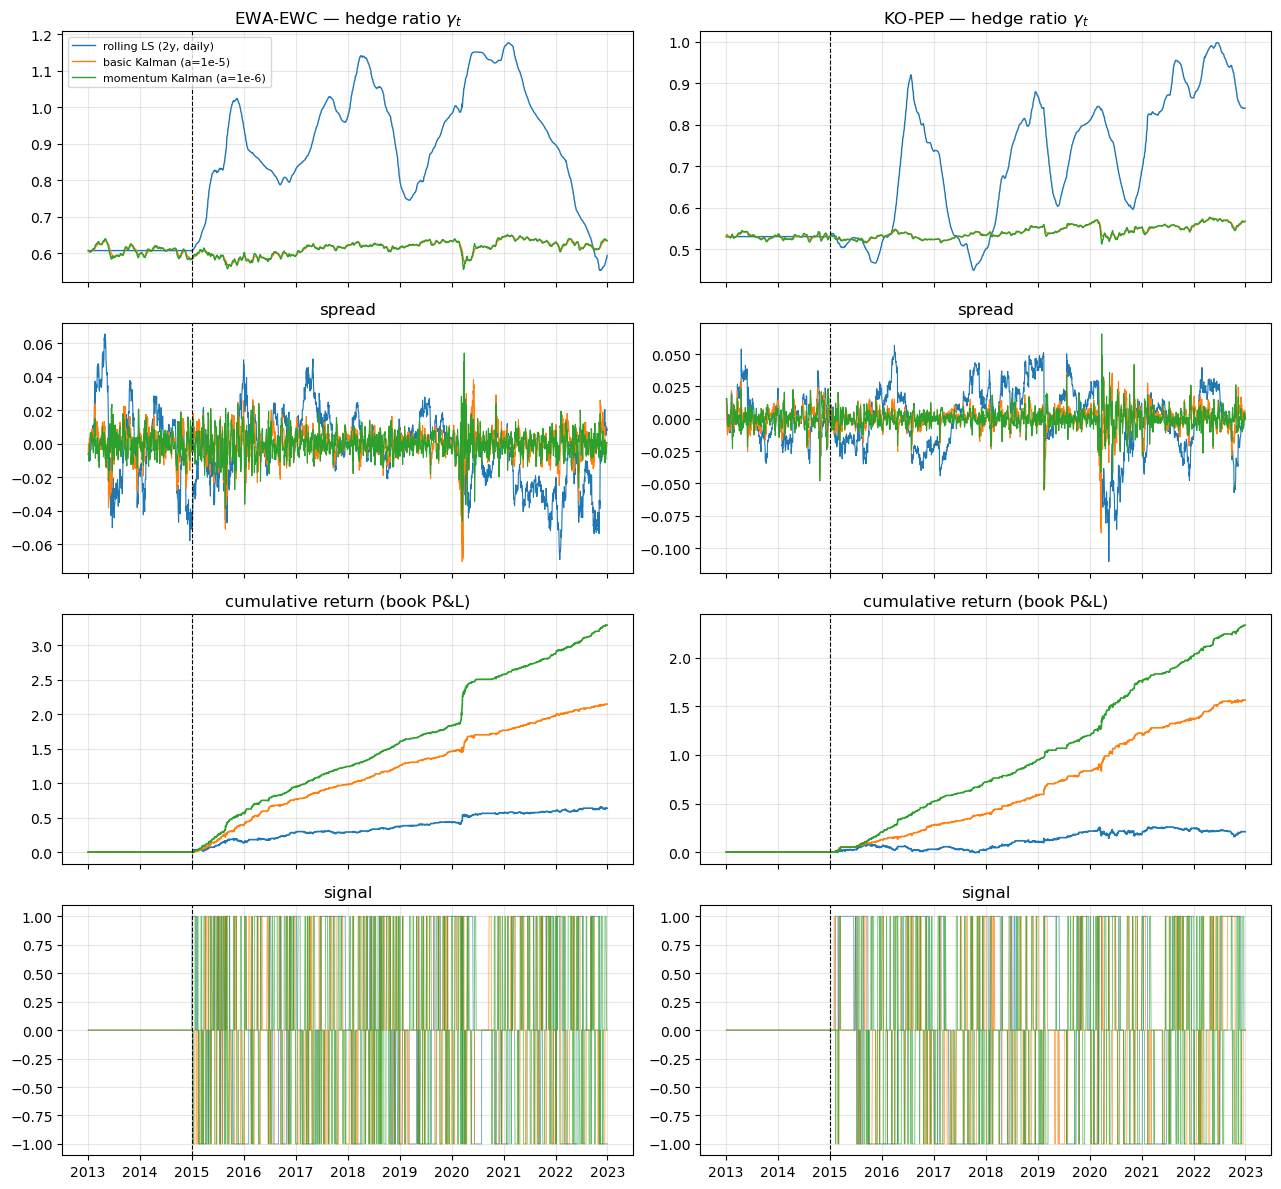

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(13, 12), sharex="col")
for col, (name, res) in enumerate([("EWA-EWC", ewa_ewc), ("KO-PEP", ko_pep)]):
    idx = res[HEDGES[0]]["idx"]
    for h in HEDGES:
        axes[0, col].plot(idx, res[h]["gamma"], lw=1, label=h)
        axes[1, col].plot(idx, res[h]["spread"], lw=0.8, label=h)
        axes[2, col].plot(idx, res[h]["cumret"], lw=1.2, label=h)
        axes[3, col].plot(idx, res[h]["signal"], lw=0.6, alpha=0.7, label=h)
    for r in range(4):
        axes[r, col].axvline(idx[T_TRN], color="k", ls="--", lw=0.8)
    axes[0, col].set_title(f"{name} — hedge ratio $\\gamma_t$")
    axes[1, col].set_title("spread")
    axes[2, col].set_title("cumulative return (book P&L)")
    axes[3, col].set_title("signal")
axes[0, 0].legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

The book's own reported final cumulative returns (read off slide 81 for EWA–EWC; off the slide 85–88
plots for KO–PEP, which are not printed to three decimals in the deck) next to what this notebook's
translation of the same R code produces on the day lake's total-return log prices:

In [5]:
book_reported = {
    "EWA-EWC": {"rolling LS (2y, daily)": 0.6, "basic Kalman (a=1e-5)": 2.0, "momentum Kalman (a=1e-6)": 3.2},
    "KO-PEP":  {"rolling LS (2y, daily)": 0.2, "basic Kalman (a=1e-5)": 1.5, "momentum Kalman (a=1e-6)": 2.0},
}
repro = {"EWA-EWC": ewa_ewc, "KO-PEP": ko_pep}

rows = []
for pair, res in repro.items():
    for h in HEDGES:
        rows.append({"pair": pair, "hedge": h,
                     "book (deck)": book_reported[pair][h],
                     "reproduced (day lake)": round(float(res[h]["cumret"][-1]), 3)})
repro_table = pd.DataFrame(rows).set_index(["pair", "hedge"])
repro_table["gap (%)"] = ((repro_table["reproduced (day lake)"] - repro_table["book (deck)"])
                          / repro_table["book (deck)"] * 100).round(1)
print(repro_table.to_string())
outlier = repro_table["gap (%)"].abs().idxmax()
others = repro_table.drop(index=outlier)["gap (%)"].abs()
print(f"largest gap: {outlier[0]} {outlier[1]} at {repro_table.loc[outlier, 'gap (%)']:+.1f}%; "
      f"next-largest gap among the rest: {others.max():.2f}%")

                                  book (deck)  reproduced (day lake)  gap (%)
pair    hedge                                                                
EWA-EWC rolling LS (2y, daily)            0.6                  0.634      5.7
        basic Kalman (a=1e-5)             2.0                  2.145      7.3
        momentum Kalman (a=1e-6)          3.2                  3.290      2.8
KO-PEP  rolling LS (2y, daily)            0.2                  0.209      4.5
        basic Kalman (a=1e-5)             1.5                  1.568      4.5
        momentum Kalman (a=1e-6)          2.0                  2.338     16.9
largest gap: KO-PEP momentum Kalman (a=1e-6) at +16.9%; next-largest gap among the rest: 7.30%


Every hedge on both pairs reproduces the book's qualitative pattern — momentum Kalman beats basic Kalman
beats rolling LS by a wide margin. Five of the six book/reproduced pairs sit within about a decimal
place's reading error of the deck's rounded numbers — the gaps printed above run from 2.8% to 7.3% —
which is as much agreement as a chart read to one decimal place can confirm. KO-PEP's momentum Kalman
value is the outlier at +16.9%, more than double the next-largest gap; it does not change the ranking
(momentum Kalman is still the largest book return for both pairs). Unlike rolling LS, which is invariant
to a constant rescaling of the price level, the book's Kalman spec is not — its `Q` and `V0` are scaled by
`var(y2)` and its observation equation carries `y2` directly — so the cell below reruns the whole pipeline
on four more price bases (two rescaled total-return anchors, one end-anchored like Yahoo's convention, and
raw close with no dividend reinvestment at all) to see how much of the gap that non-invariance could
explain.

In [6]:
# Basis sensitivity: rerun the identical pipeline (rolling LS + both Kalman specs + BB signal) on four
# more price bases. "TR x0.5"/"TR x2" rescale the total-return anchor price; "TR end-anchored" anchors
# the same total-return path to the LAST close instead of the first (Yahoo's own convention backs
# adjusted closes out from the most recent price); "raw close" drops total-return adjustment altogether
# (no dividend reinvestment). The first three are all constant rescalings of the same cumulative-return
# path; only "raw close" is a genuinely different return series.
def y_basis(ticker, basis, lo=LO, hi=HI):
    if basis == "raw close":
        return np.log(px[ticker].loc[lo:hi].dropna())
    r = ret[ticker].loc[lo:hi].fillna(0.0).copy()
    r.iloc[0] = 0.0
    level_rel = (1.0 + r).cumprod()
    p0 = px[ticker].loc[lo:hi].iloc[0]
    if basis == "TR x0.5":
        anchor = 0.5 * p0
    elif basis == "TR x2":
        anchor = 2.0 * p0
    elif basis == "TR end-anchored":
        p_end = px[ticker].loc[lo:hi].iloc[-1]
        anchor = p_end / level_rel.iloc[-1]
    else:
        raise ValueError(basis)
    return np.log(anchor * level_rel)

BASES = ["TR (start-anchored, notebook default)", "TR x0.5", "TR x2", "TR end-anchored", "raw close"]

def run_pair_basis(t1, t2, basis):
    if basis == "TR (start-anchored, notebook default)":
        y1, y2 = logtr(t1).to_numpy(), logtr(t2).to_numpy()
    else:
        y1, y2 = y_basis(t1, basis).to_numpy(), y_basis(t2, basis).to_numpy()
    mu_ls, g_ls = rolling_ls(y1, y2)
    mu_kb, g_kb = kalman(y1, y2, alpha=1e-5)
    mu_km, g_km = kalman(y1, y2, alpha=1e-6, momentum=True)
    rows = {}
    for name, (mu, g) in zip(HEDGES, [(mu_ls, g_ls), (mu_kb, g_kb), (mu_km, g_km)]):
        w = np.column_stack([np.ones(len(g)), -g]) / (1.0 + g)[:, None]
        c = mu / (1.0 + g)
        y = np.column_stack([y1, y2])
        spread = (w * y).sum(axis=1) - c
        sig = bb_threshold_signal(spread, start=T_TRN)
        dec = decompose_spread_pnl(y, w, c, sig)
        book = float(dec["book"].sum())
        phantom = float(dec["revaluation"].sum() / book) if book != 0 else float("nan")
        rows[name] = dict(book=book, phantom=phantom)
    return rows

sweep_rows = []
for pair, (t1, t2) in [("EWA-EWC", ("EWA", "EWC")), ("KO-PEP", ("KO", "PEP"))]:
    for basis in BASES:
        res_here = run_pair_basis(t1, t2, basis)
        for h in HEDGES:
            sweep_rows.append({"pair": pair, "hedge": h, "basis": basis,
                                "book": round(res_here[h]["book"], 3),
                                "phantom share": round(res_here[h]["phantom"], 3)})
sweep_table = pd.DataFrame(sweep_rows).set_index(["pair", "hedge", "basis"])
print(sweep_table.to_string())

print()
sweep_summary = []
for pair in ["EWA-EWC", "KO-PEP"]:
    for h in HEDGES:
        sub = sweep_table.loc[(pair, h)]
        tr_only = sub.drop(index="raw close")
        sweep_summary.append({
            "pair": pair, "hedge": h,
            "book min-max (TR bases only)": f"{tr_only['book'].min():.3f}-{tr_only['book'].max():.3f}",
            "book min-max (all 5 bases)": f"{sub['book'].min():.3f}-{sub['book'].max():.3f}",
            "phantom share min-max (all 5 bases)": f"{sub['phantom share'].min():.3f}-{sub['phantom share'].max():.3f}",
        })
sweep_summary = pd.DataFrame(sweep_summary).set_index(["pair", "hedge"])
print(sweep_summary.to_string())

                                                                         book  phantom share
pair    hedge                    basis                                                      
EWA-EWC rolling LS (2y, daily)   TR (start-anchored, notebook default)  0.634          0.167
        basic Kalman (a=1e-5)    TR (start-anchored, notebook default)  2.145          0.748
        momentum Kalman (a=1e-6) TR (start-anchored, notebook default)  3.290          0.833
        rolling LS (2y, daily)   TR x0.5                                0.634          0.167
        basic Kalman (a=1e-5)    TR x0.5                                1.854          0.774
        momentum Kalman (a=1e-6) TR x0.5                                3.089          0.838
        rolling LS (2y, daily)   TR x2                                  0.634          0.167
        basic Kalman (a=1e-5)    TR x2                                  2.273          0.783
        momentum Kalman (a=1e-6) TR x2                                

The price basis differs slightly from the book's own (day-lake total-return closes here, Yahoo adjusted
closes there — notebook 06 measured that the two lakes agree on returns but not on levels), so an exact
match to three decimals was never the bar. But the sweep above shows the basis is *not* what explains
KO-PEP's momentum-Kalman outlier: on every total-return basis (start-anchored, `x0.5`, `x2`, end-anchored)
its book value sits in 2.256-2.382 — a range of 0.126, about 5% of the value — and never lands closer than
+12.8% to the deck's reported 2.0; adding raw close (a genuinely different return series, with no dividend
reinvestment) only widens that range to 2.256-2.619. The other Kalman cells move far more over the same
sweep: EWA-EWC's basic Kalman spans 1.854-2.555 (33% of its value) and momentum Kalman 3.089-4.257 (36%);
KO-PEP's basic Kalman spans 1.488-1.889 (26%). So the cell with the largest gap to the deck is, if anything,
the *least* basis-sensitive of the four Kalman cells checked here — price basis cannot be the explanation.
The likelier reason, per §7, is that the deck's KO-PEP numbers were read off a plot to one decimal place
rather than taken from a printed table, so the book's own reference value carries reading error this
notebook's numbers do not; the residual gap is left unexplained. What the sweep does confirm is the general
point the prose above made: rolling LS's book value does not move at all across the four total-return bases
(0.634 stays 0.634 for EWA-EWC, 0.209 for KO-PEP), while both Kalman specs move by tenths even before raw
close is added, because `Q` and `V0` are scaled by `var(y2)` and the observation equation carries `y2`
directly. The **phantom share** moves far less than the book value does: across all five bases it stays in
0.748-0.843 (basic Kalman) and 0.822-0.852 (momentum Kalman) on EWA-EWC, and 0.903-0.959 / 1.007-1.082 on
KO-PEP — every Kalman cell on every basis has a phantom share at or above three-quarters of the book line,
which is the robustness claim §4 relies on.

## 4. The split: book, tradable, revaluation

In [7]:
def split_pair(res, cost_rows_by_ticker):
    rows = []
    curves = {}
    for h in HEDGES:
        r = res[h]
        out = decompose_spread_pnl(r["y"], r["w"], r["c"], r["signal"])
        book, tradable, revaluation = out["book"], out["tradable"], out["revaluation"]
        signal_lag = np.r_[0.0, r["signal"][:-1]]
        spread_lag = np.r_[0.0, r["spread"][:-1]]
        signed_lagged_spread = -signal_lag * spread_lag

        # "trades" = round trips (entries + reversals), not every position change: a change from
        # 0 to a nonzero signal (entry) or from +1 straight to -1 (reversal) opens a new position,
        # but a change to 0 (exit) closes one without opening another, so counting all three as
        # "trades" understates the average holding period per round trip by roughly 2x.
        prev_sig, new_sig = r["signal"][:-1], r["signal"][1:]
        changed = new_sig != prev_sig
        entries = int(np.sum(changed & (prev_sig == 0)))
        reversals = int(np.sum(changed & (prev_sig != 0) & (new_sig != 0)))
        trades = entries + reversals
        in_pos_days = int((r["signal"][T_TRN:] != 0).sum())
        avg_hold = in_pos_days / max(trades, 1)

        # measured one-way costs (bps), matched by year, median fallback for missing years
        pos = r["signal"][:, None] * r["w"]
        dpos = np.abs(np.vstack([pos[:1], np.diff(pos, axis=0)]))
        cvec = np.column_stack([
            np.array([cost_rows_by_ticker[j].get(y, cost_rows_by_ticker[j].median()) for y in r["idx"].year])
            for j in (0, 1)
        ]) / 1e4
        fees = (dpos * cvec).sum(axis=1)
        net_tradable = tradable - fees

        sh = lambda x: float(x[T_TRN:].mean() / x[T_TRN:].std() * np.sqrt(252)) if x[T_TRN:].std() > 0 else float("nan")
        # standard error of the cumulative tradable line over the traded span (iid daily P&L), and its t
        n_tr = len(tradable) - T_TRN
        se_tr = float(tradable[T_TRN:].std(ddof=1) * np.sqrt(n_tr))
        t_tr = float(tradable[T_TRN:].sum() / se_tr) if se_tr > 0 else float("nan")

        rows.append({
            "hedge": h,
            "book": float(book.sum()), "tradable": float(tradable.sum()), "revaluation": float(revaluation.sum()),
            "phantom share": float(revaluation.sum() / book.sum()),
            "corr(revaluation, signed lagged spread)": float(np.corrcoef(revaluation[T_TRN:], signed_lagged_spread[T_TRN:])[0, 1]),
            "trades": trades, "avg holding (days)": avg_hold,
            "fees": float(fees.sum()), "net tradable": float(net_tradable.sum()),
            "Sharpe tradable": sh(tradable), "Sharpe net": sh(net_tradable),
            "SE tradable": se_tr, "t tradable": t_tr,
        })
        curves[h] = dict(book=book, tradable=tradable, revaluation=revaluation)
    return pd.DataFrame(rows).set_index("hedge"), curves

cost_ewa_ewc = {i: cost_tbl[cost_tbl.ticker.eq(t)].groupby("year")["cost_used"].median() for i, t in enumerate(["EWA", "EWC"])}
cost_ko_pep  = {i: cost_tbl[cost_tbl.ticker.eq(t)].groupby("year")["cost_used"].median() for i, t in enumerate(["KO", "PEP"])}

table_ewa_ewc, curves_ewa_ewc = split_pair(ewa_ewc, cost_ewa_ewc)
table_ko_pep,  curves_ko_pep  = split_pair(ko_pep,  cost_ko_pep)

print("=== EWA-EWC ===")
print(table_ewa_ewc.round(3).T.to_string())
print()
print("=== KO-PEP ===")
print(table_ko_pep.round(3).T.to_string())

=== EWA-EWC ===
hedge                                    rolling LS (2y, daily)  basic Kalman (a=1e-5)  momentum Kalman (a=1e-6)
book                                                      0.634                  2.145                     3.290
tradable                                                  0.528                  0.540                     0.550
revaluation                                               0.106                  1.605                     2.740
phantom share                                             0.167                  0.748                     0.833
corr(revaluation, signed lagged spread)                   0.519                  0.996                     0.862
trades                                                   51.000                153.000                   228.000
avg holding (days)                                       27.176                  7.458                     4.732
fees                                                      0.020                 

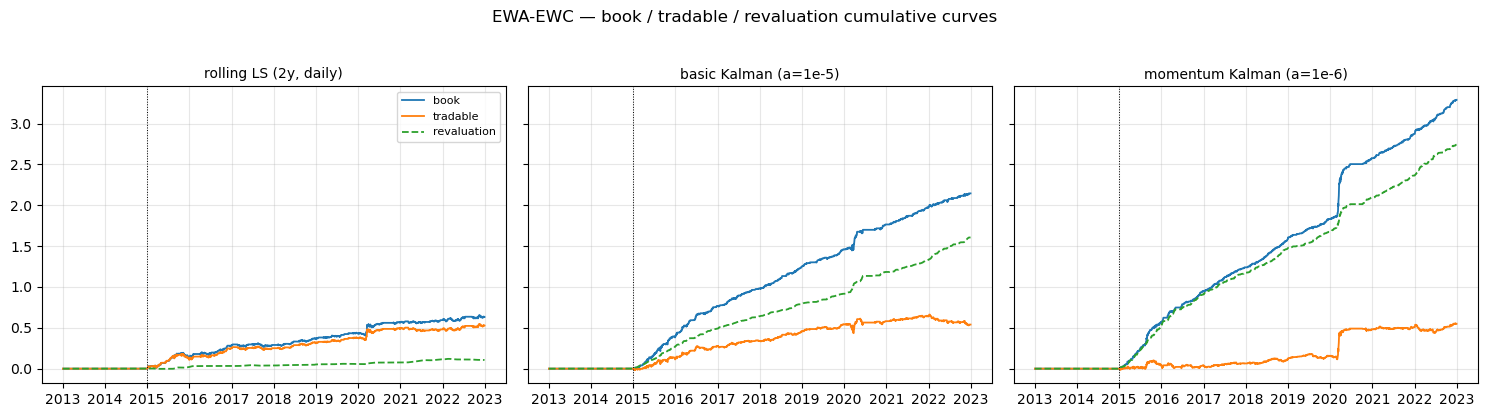

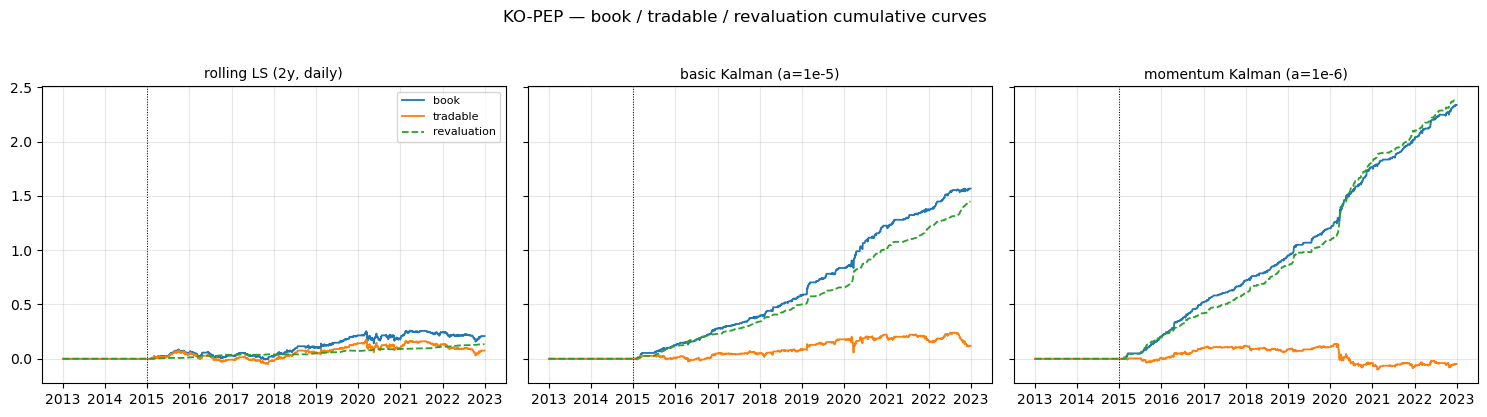

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, h in zip(axes, HEDGES):
    idx = ewa_ewc[h]["idx"]
    c = curves_ewa_ewc[h]
    ax.plot(idx, np.cumsum(c["book"]), label="book", lw=1.3)
    ax.plot(idx, np.cumsum(c["tradable"]), label="tradable", lw=1.3)
    ax.plot(idx, np.cumsum(c["revaluation"]), label="revaluation", lw=1.3, ls="--")
    ax.axvline(idx[T_TRN], color="k", ls=":", lw=0.7)
    ax.set_title(h, fontsize=10)
axes[0].legend(fontsize=8)
fig.suptitle("EWA-EWC — book / tradable / revaluation cumulative curves", y=1.03)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, h in zip(axes, HEDGES):
    idx = ko_pep[h]["idx"]
    c = curves_ko_pep[h]
    ax.plot(idx, np.cumsum(c["book"]), label="book", lw=1.3)
    ax.plot(idx, np.cumsum(c["tradable"]), label="tradable", lw=1.3)
    ax.plot(idx, np.cumsum(c["revaluation"]), label="revaluation", lw=1.3, ls="--")
    ax.axvline(idx[T_TRN], color="k", ls=":", lw=0.7)
    ax.set_title(h, fontsize=10)
axes[0].legend(fontsize=8)
fig.suptitle("KO-PEP — book / tradable / revaluation cumulative curves", y=1.03)
plt.tight_layout()
plt.show()

Two things hold across every hedge and both pairs: the identity `book == tradable + revaluation` (built
into `decompose_spread_pnl` and separately unit-tested), and a revaluation term whose correlation with the
signed lagged spread is strongly positive — the mechanism from §2, not noise. What differs sharply is the
**tradable** line, which is the only one of the three anyone could have actually earned:

* **EWA-EWC.** The tradable cumulative returns — 0.528, 0.540 and 0.550 — are indistinguishable across
  the three hedges: each carries a standard error of 0.18–0.23 (t = 3.0, 2.3 and 2.4), so the differences
  between them are far inside the noise, while the book line ranges from 0.634 to 3.290. Momentum Kalman's headline advantage
  over rolling LS, 5.19x on the book line, shrinks to essentially nothing once the revaluation term is
  removed. The gain the book attributes to a "faster" hedge is a faster filter marking itself against more
  recent prices, not a better trade.
* **KO-PEP.** The tradable line is small and, for momentum Kalman, slightly negative — 0.076, 0.120,
  -0.046, with t = 0.4, 0.7 and -0.3 against standard errors of about 0.18 — indistinguishable from zero. Every point of the book
  line's 2.338 headline for momentum Kalman is revaluation.

In [9]:
print("EWA-EWC tradable (final):", {h: round(float(table_ewa_ewc.loc[h, "tradable"]), 3) for h in HEDGES})
print("EWA-EWC book (final):    ", {h: round(float(table_ewa_ewc.loc[h, "book"]), 3) for h in HEDGES})
print("EWA-EWC momentum/rollingLS book ratio:",
      round(float(table_ewa_ewc.loc[HEDGES[2], "book"] / table_ewa_ewc.loc[HEDGES[0], "book"]), 2))
print("KO-PEP tradable (final): ", {h: round(float(table_ko_pep.loc[h, "tradable"]), 3) for h in HEDGES})
print("EWA-EWC tradable SE:     ", {h: round(float(table_ewa_ewc.loc[h, "SE tradable"]), 2) for h in HEDGES},
      " t:", {h: round(float(table_ewa_ewc.loc[h, "t tradable"]), 1) for h in HEDGES})
print("KO-PEP tradable SE:      ", {h: round(float(table_ko_pep.loc[h, "SE tradable"]), 2) for h in HEDGES},
      " t:", {h: round(float(table_ko_pep.loc[h, "t tradable"]), 1) for h in HEDGES})
print("KO-PEP book (final):     ", {h: round(float(table_ko_pep.loc[h, "book"]), 3) for h in HEDGES})

EWA-EWC tradable (final): {'rolling LS (2y, daily)': 0.528, 'basic Kalman (a=1e-5)': 0.54, 'momentum Kalman (a=1e-6)': 0.55}
EWA-EWC book (final):     {'rolling LS (2y, daily)': 0.634, 'basic Kalman (a=1e-5)': 2.145, 'momentum Kalman (a=1e-6)': 3.29}
EWA-EWC momentum/rollingLS book ratio: 5.19
KO-PEP tradable (final):  {'rolling LS (2y, daily)': 0.076, 'basic Kalman (a=1e-5)': 0.12, 'momentum Kalman (a=1e-6)': -0.046}
EWA-EWC tradable SE:      {'rolling LS (2y, daily)': 0.18, 'basic Kalman (a=1e-5)': 0.23, 'momentum Kalman (a=1e-6)': 0.23}  t: {'rolling LS (2y, daily)': 3.0, 'basic Kalman (a=1e-5)': 2.3, 'momentum Kalman (a=1e-6)': 2.4}
KO-PEP tradable SE:       {'rolling LS (2y, daily)': 0.19, 'basic Kalman (a=1e-5)': 0.18, 'momentum Kalman (a=1e-6)': 0.18}  t: {'rolling LS (2y, daily)': 0.4, 'basic Kalman (a=1e-5)': 0.7, 'momentum Kalman (a=1e-6)': -0.3}
KO-PEP book (final):      {'rolling LS (2y, daily)': 0.209, 'basic Kalman (a=1e-5)': 1.568, 'momentum Kalman (a=1e-6)': 2.338}


## 5. The repository's own accounting, made visible on real data

In [10]:
# EWA-EWC, 2013-2022, raw (non-log) closes -- the package's own price basis (nb06: returns agree,
# levels don't -- see notebook 6 -- so this is deliberately a different y than sections 2-4's log prices).
P1 = px["EWA"].loc[LO:HI].dropna()
P2 = px["EWC"].loc[LO:HI].dropna()
idx_pkg = P1.index.intersection(P2.index)
P1, P2 = P1.loc[idx_pkg], P2.loc[idx_pkg]
df_pkg = pd.DataFrame({"P1": P1, "P2": P2})
print(f"package window: {df_pkg.index[0].date()} -> {df_pkg.index[-1].date()}  ({len(df_pkg):,} sessions)")

package window: 2013-01-02 -> 2022-12-30  (2,518 sessions)


In [11]:
# Notebook 11's own fold count, cited the same way §3 cites the book's reported numbers: read off
# that notebook's own printed cell ("39 formations 2006-06-30 -> 2025-07-01"), not recomputed here --
# this notebook never loads the full cross-sectional universe notebook 11's FORMATIONS is built from.
notebook_11_reported = {"formations": 39, "span": "2006-06-30 -> 2025-07-01",
                        "source": "pairs_trading_11_daily_portfolio.ipynb, its own printed formation count"}
print(f"notebook 11 (cited): {notebook_11_reported['formations']} formations, {notebook_11_reported['span']}")

notebook 11 (cited): 39 formations, 2006-06-30 -> 2025-07-01


Notebook 11's own walk-forward design fits the package's Kalman hedge once **per fold**, on a formation
window, then freezes `F`/`Q`/`R` and continues with a pure causal recursion (`filter_kf_on_new`) over the
following trading window -- it never re-fits `em_iters=5` on bars that get traded. This section reproduces
that same two-step construction -- one formation window followed by one trading window, with the identical
`em_iters=5` keyword and the same `generate_pair_signals`/`evaluate_pair_signals` functions and thresholds
notebook 11 uses -- but as a **single** formation/trade split over the full 2013-2022 span rather than
notebook 11's 39 rolled semi-annual formations (cited above), since the goal here is an accounting-invariants
check on the package's machinery, not a realistic backtest (see §7).

In [12]:
# One formation/trade fold, notebook 11's own FORM_YEARS=2: EM (em_iters=5) fits only the formation
# window; F/Q/R are then frozen and filter_kf_on_new continues on the trade window with a pure,
# one-bar-at-a-time recursion -- the identical two-step construction notebook 11's run_pair() uses.
FORM_YEARS_PKG = 2
formation_pkg = df_pkg.index[0] + pd.DateOffset(years=FORM_YEARS_PKG)
form_pkg  = df_pkg.loc[df_pkg.index <= formation_pkg]
trade_pkg = df_pkg.loc[df_pkg.index >  formation_pkg]
print(f"formation: {form_pkg.index[0].date()} -> {form_pkg.index[-1].date()}  ({len(form_pkg):,} sessions)")
print(f"trade:     {trade_pkg.index[0].date()} -> {trade_pkg.index[-1].date()}  ({len(trade_pkg):,} sessions)")

_, _, st_form, params_form = _kalman_dynamic_hedge("P1", "P2", form_pkg, q=1e-5, em_iters=5, mode="filter",
                                                   return_params=True)
frozen = {k: params_form[k] for k in ("F", "Q", "R")}
st_trade, _ = filter_kf_on_new(trade_pkg["P1"], trade_pkg["P2"], frozen=frozen,
                               last_state=(params_form["last_state_mean"], params_form["last_state_cov"]),
                               mode="filter")
states = trade_pkg[["P1", "P2"]].join(st_trade[["alpha", "beta", "resid"]], how="inner")
print("beta range (trade window):", round(float(states["beta"].min()), 3), "to", round(float(states["beta"].max()), 3))

resid_form = st_form["resid"].dropna()
hl = estimate_halflife(resid_form)
win = int(np.clip(3 * hl, 20, 250)) if np.isfinite(hl) else 60
print(f"formation residual half-life: {hl:.1f} sessions -> z-score look-back {win} (notebook 11's own rule)")

sig_pkg = generate_pair_signals(states, z_method="robust", z_window=win, z_history=resid_form,
                                z_entry=2.0, z_exit=0.5, z_stop=4.0, capital_per_pair=10_000.0)
daily_pkg, trades_pkg, summ_pkg = evaluate_pair_signals(states[["P1", "P2"]], sig_pkg, cost_bps=0.0,
                                                        borrow_bps_per_year=0.0, capital_base=10_000.0)
print(f"package: {len(trades_pkg)} round trips, package P&L (pnl_gross, cumulative) = ${daily_pkg['pnl_gross'].sum():,.2f}")

formation: 2013-01-02 -> 2015-01-02  (505 sessions)
trade:     2015-01-05 -> 2022-12-30  (2,013 sessions)


beta range (trade window): 0.551 to 0.733
formation residual half-life: 0.7 sessions -> z-score look-back 20 (notebook 11's own rule)
package: 119 round trips, package P&L (pnl_gross, cumulative) = $1,652.83


**A second, separate look-ahead -- and why the construction above avoids it.** `mode="filter"` is causal
for the *recursion*: the state at bar $t$ conditions only on bars $\le t$. `em_iters=5` is not automatically
causal for the *parameters* that recursion uses -- pykalman's `.em()` runs batch EM over **whatever window
it is given** before any filtering starts, fitting `transition_covariance`, `observation_covariance` and (by
`em_vars`'s default) the initial-state prior to that window at once. The construction above never lets EM
see a traded bar: `em_iters=5` runs once, on `form_pkg` alone, before `trade_pkg` is even sliced off, and the
recursion that follows only ever looks backward. Two perturbation tests make the contrast concrete: nudge a
late price and re-fit, once under the fold construction above and once under a single batch EM fit over the
*whole* form+trade span (a construction neither notebook 11 nor the cell above uses).

In [13]:
# (a) The fold construction above: EM confined to the formation window, F/Q/R frozen, filter_kf_on_new
# continues on the trade window. Perturb a LATE trade-window price; an EARLY trade-window beta should
# not move at all -- EM never saw the trade window, and the recursion cannot look forward.
trade_pert = trade_pkg.copy()
perturb_at = len(trade_pkg) - 50
trade_pert.iloc[perturb_at, trade_pert.columns.get_loc("P1")] *= 1.05
st_trade_pert, _ = filter_kf_on_new(trade_pert["P1"], trade_pert["P2"], frozen=frozen,
                                    last_state=(params_form["last_state_mean"], params_form["last_state_cov"]),
                                    mode="filter")
early = slice(0, 200)
shift_fold = float(np.max(np.abs(st_trade["beta"].to_numpy()[early] - st_trade_pert["beta"].to_numpy()[early])))
print("fold construction (EM on formation only, frozen, filter_kf_on_new on trade):")
print(f"  perturbed trade bar {perturb_at} of {len(trade_pkg)} (+5% on P1); max |beta shift| over trade bars 0-199: {shift_fold:.2e}")

# (b) Contrast -- NOT what notebook 11 or the fold above does: a single batch EM fit over the whole
# form+trade span, so EM itself is exposed to bars that will be traded.
df_pert_whole = df_pkg.copy()
perturb_at_whole = len(df_pkg) - 50
df_pert_whole.iloc[perturb_at_whole, df_pert_whole.columns.get_loc("P1")] *= 1.05
_, _, states_base_whole, _ = _kalman_dynamic_hedge("P1", "P2", df_pkg,  q=1e-5, em_iters=5, mode="filter", return_params=True)
_, _, states_pert_whole, _ = _kalman_dynamic_hedge("P1", "P2", df_pert_whole, q=1e-5, em_iters=5, mode="filter", return_params=True)
early_whole = slice(0, 200)
shift_whole = float(np.max(np.abs(states_base_whole["beta"].to_numpy()[early_whole] - states_pert_whole["beta"].to_numpy()[early_whole])))
print("single batch EM over the WHOLE span (neither notebook 11 nor the fold above -- shown as a caution):")
print(f"  perturbed bar {perturb_at_whole} of {len(df_pkg)} (+5% on P1); max |beta shift| over bars 0-199: {shift_whole:.2e}")

fold construction (EM on formation only, frozen, filter_kf_on_new on trade):
  perturbed trade bar 1963 of 2013 (+5% on P1); max |beta shift| over trade bars 0-199: 0.00e+00


single batch EM over the WHOLE span (neither notebook 11 nor the fold above -- shown as a caution):
  perturbed bar 2468 of 2518 (+5% on P1); max |beta shift| over bars 0-199: 1.36e-03


The fold construction above shows no shift at all: EM never touches the trade window, so there is nothing
for the perturbation to leak into, and the per-bar recursion is causal by construction. A single batch EM
fit over the whole span -- which is not what notebook 11 does, and not what the construction above does
either -- does leak: an early beta moves in response to a price perturbed hundreds of bars later. It is the
same class of defect as `mode="smooth"`'s whole-sample conditioning (§0), and it is worth knowing about
because `em_iters=5` alone does not guarantee causality -- the window it is given has to matter too -- but
it is not a defect in notebook 11's own formation/trade design, which is exactly why the fold above is built
to match that design rather than a single whole-window fit.

**(i) Independent rebuild.** `evaluate_pair_signals` books `pnl_gross_t = n1_t dP1_t + n2_t dP2_t` on the
executed share holdings `n1, n2` (already next-bar-timed) and raw price differences. Recomputing that from
nothing but the holdings the package actually reported and the same price series reproduces its P&L to
machine precision — this is `decompose_spread_pnl`'s `tradable` line by construction, per the engine's
pinned relation.

In [14]:
P1_trade, P2_trade = states["P1"], states["P2"]
n1_exe = sig_pkg["n1"].to_numpy(); n2_exe = sig_pkg["n2"].to_numpy()
dP1 = P1_trade.diff().fillna(0.0).to_numpy(); dP2 = P2_trade.diff().fillna(0.0).to_numpy()
pnl_manual = n1_exe * dP1 + n2_exe * dP2
print("max |independent rebuild - package pnl_gross| ($):", float(np.max(np.abs(pnl_manual - daily_pkg["pnl_gross"].to_numpy()))))
print("independent rebuild, cumulative: $", round(float(pnl_manual.sum()), 2))

max |independent rebuild - package pnl_gross| ($): 0.0
independent rebuild, cumulative: $ 1652.83


**(ii) The book-style line on the package's own spread.** The package's own hedge already defines a spread
-- `resid_t = P1_t - alpha_t - beta_t P2_t`, i.e. weight `w_t=[1,-beta_t]` and centering term `c_t=alpha_t`.
Feeding `decompose_spread_pnl` that per-share weight together with the *share count actually held*
(`n1`, undelayed) as `signal` reproduces the tradable line exactly (confirming (i) a second way, inside the
engine, since `signal * w = [n1, -beta n1] = [n1, n2]` is precisely the executed position) and, in the same
call, gives the book-style `signal * diff(spread)` line nobody asked the package to compute: what a naive
backtest would have booked by diffing the package's own per-share residual instead of applying the executed
holdings to the price changes directly.

In [15]:
n1_dec = np.r_[n1_exe[1:], n1_exe[-1]]   # undo generate_pair_signals' one-bar exec_lag: n1_exe[t]=n1_dec[t-1]
beta_trade = states["beta"].to_numpy()
alpha_trade = states["alpha"].to_numpy()
w_pkg = np.column_stack([np.ones(len(beta_trade)), -beta_trade])
y_pkg = np.column_stack([P1_trade.to_numpy(), P2_trade.to_numpy()])

out_pkg = decompose_spread_pnl(y_pkg, w_pkg, alpha_trade, n1_dec)
print("tradable vs package pnl_gross, max abs diff ($):",
      float(np.max(np.abs(out_pkg["tradable"] - daily_pkg["pnl_gross"].to_numpy()))))
print(f"book (naive diff-of-resid), cumulative:     ${out_pkg['book'].sum():,.2f}")
print(f"tradable (= package pnl_gross), cumulative: ${out_pkg['tradable'].sum():,.2f}")
print(f"revaluation, cumulative:                    ${out_pkg['revaluation'].sum():,.2f}")
print("revaluation as a fraction of the book line:", round(float(out_pkg["revaluation"].sum() / out_pkg["book"].sum()), 3))
print("book / tradable ratio (how much a naive diff(resid) backtest would overstate the real P&L):",
      round(float(out_pkg["book"].sum() / out_pkg["tradable"].sum()), 2))

tradable vs package pnl_gross, max abs diff ($): 5.684341886080802e-14
book (naive diff-of-resid), cumulative:     $3,516.67
tradable (= package pnl_gross), cumulative: $1,652.83
revaluation, cumulative:                    $1,863.83
revaluation as a fraction of the book line: 0.53
book / tradable ratio (how much a naive diff(resid) backtest would overstate the real P&L): 2.13


The `tradable` line matches the package's real, executed P&L to numerical precision (the two ways of
computing it agree to the cent: $1,652.83 both times). The naive book line -- $3,516.67 -- overstates it by
2.13x, with $1,863.83 (53% of the book line) sitting in revaluation, for the same reason as §4: `beta_t` is
not fixed (it ranges from 0.551 to 0.733 over the trade window), so `signal * diff(spread)` mixes the
position's real return with the filter re-marking `alpha_t`/`beta_t` against the day's price level. The
package itself is free of this defect only because `evaluate_pair_signals` applies the *executed* holdings
directly to price changes rather than diffing a re-priced spread — nothing about its hedge is unusually
slow (its beta moved between 0.551 and 0.733 over the trade window), so a diff-of-resid backtest built on this same
package output would still overstate gross P&L by a factor of roughly two, the same mechanism as §4's
phantom share, now shown inside the package's own signal/evaluation pipeline rather than a textbook's.

## 6. Aside — the deck's threshold optimization

In [16]:
# Slide 61: without costs, s0* = argmax_s0 (1-Phi(s0))*s0. With a round-trip cost c (same units as
# sigma*s0, the profit per trade), the objective becomes (1-Phi(s0))*(sigma*s0 - c).
def s0_star(sigma, c):
    obj = lambda s0: -(1 - norm.cdf(s0)) * (sigma * s0 - c)
    return float(minimize_scalar(obj, bounds=(1e-6, 5.0), method="bounded").x)

s0_no_cost = s0_star(1.0, 0.0)  # objective is scale-free in sigma when c=0
print("s0* (no cost):", round(s0_no_cost, 3))
book_s0_star = 0.75  # deck's reported value, slide 61, no cost
print("book s0* (slide 61, no cost):", book_s0_star)

rows = []
for pair, (t1, t2), res in [("EWA-EWC", ("EWA", "EWC"), ewa_ewc), ("KO-PEP", ("KO", "PEP"), ko_pep)]:
    spread = res["basic Kalman (a=1e-5)"]["spread"]
    sigma = float(spread[T_TRN:].std())
    w = res["basic Kalman (a=1e-5)"]["w"]
    mean_abs_w1 = float(np.abs(w[T_TRN:, 0]).mean())
    mean_abs_w2 = float(np.abs(w[T_TRN:, 1]).mean())
    print(f"{pair}: mean|w1|={mean_abs_w1:.3f}  mean|w2|={mean_abs_w2:.3f}  "
          f"(sum {mean_abs_w1 + mean_abs_w2:.3f} -- the spread is built leverage-1, w=[1,-gamma]/(1+gamma))")
    m1 = float(cost_tbl[cost_tbl.ticker.eq(t1)].groupby("year")["cost_used"].median().median())
    m2 = float(cost_tbl[cost_tbl.ticker.eq(t2)].groupby("year")["cost_used"].median().median())
    # sigma*s0 is profit per $1 of GROSS notional, since |w1|+|w2|=1 by construction (printed above) --
    # not profit per $1 per leg. A cost per leg must therefore be weighted by that leg's share of gross
    # notional (mean|w_i|), not charged as if each leg traded the full $1. A round trip is one open plus
    # one close, i.e. two transactions on that same $1 of gross notional.
    c_measured = 2.0 * (mean_abs_w1 * m1 + mean_abs_w2 * m2) / 1e4
    for label, c in [("0 bps", 0.0), ("5 bps", 2 * 5.0 / 1e4), ("10 bps", 2 * 10.0 / 1e4), ("measured", c_measured)]:
        rows.append({"pair": pair, "cost": label, "c (fraction)": round(c, 5), "s0*": round(s0_star(sigma, c), 3)})
threshold_table = pd.DataFrame(rows).set_index(["pair", "cost"])
print()
print(threshold_table.to_string())

s0* (no cost): 0.752
book s0* (slide 61, no cost): 0.75
EWA-EWC: mean|w1|=0.620  mean|w2|=0.380  (sum 1.000 -- the spread is built leverage-1, w=[1,-gamma]/(1+gamma))
KO-PEP: mean|w1|=0.648  mean|w2|=0.352  (sum 1.000 -- the spread is built leverage-1, w=[1,-gamma]/(1+gamma))

                  c (fraction)    s0*
pair    cost                         
EWA-EWC 0 bps           0.0000  0.752
        5 bps           0.0010  0.829
        10 bps          0.0020  0.907
        measured        0.0004  0.782
KO-PEP  0 bps           0.0000  0.752
        5 bps           0.0010  0.826
        10 bps          0.0020  0.902
        measured        0.0002  0.766


At zero cost the optimal threshold is 0.752 in z-score units — the deck's reported 0.75 (slide 61). The
`sigma*s0` term in the objective is profit per $1 of *gross* notional, because the spread's own weights sum
to $1 of gross exposure by construction (`mean|w1| + mean|w2| = 1.000` for both pairs, printed above) — the
same leverage-1 convention §4's fee line already uses. A round-trip cost must therefore be weighted by each
leg's *share* of that $1, not charged as if each leg traded the full dollar: at a flat 5 bps one-way per leg
that is a round-trip cost of `2 * 5 bps = 10 bps` of gross notional (one open, one close, on $1 total), not
`4 * 5 = 20 bps`. On that convention, both pairs' measured round-trip costs are small enough (a few bp of
spread volatility) that the optimum barely moves: EWA-EWC's threshold shifts from 0.752 to 0.782 and
KO-PEP's from 0.752 to 0.766. A flat 5 bps one-way per leg moves the threshold to 0.829 (EWA-EWC) / 0.826
(KO-PEP), and 10 bps to 0.907 / 0.902 — about one to two tenths of a z-score at 5-10 bps, well above
anything this repository's own measured costs produce, but far smaller than a notional convention that
double-charges each leg would suggest.

## 7. Honest assessment

In [17]:
print("sections executed:", 7)

sections executed: 7


* **This is teaching code that says it ignores costs, and this notebook mostly keeps it that way.**
  §3 reproduces the book's own zero-cost accounting and §6 adds costs to its threshold rule; §4 layers measured costs on the tradable line,
  but the book's headline curves (§3) are, as advertised, gross of everything, and §5's package-accounting
  check is zero-cost throughout as well.
* **Only the chapter's R code was checked against, not its prose.** The slide deck's KO-PEP final values
  were read off a plot axis to one decimal place, not taken from a printed table, and the deck's text was
  not re-read line by line for caveats this notebook might be missing.
* **Different price basis from the book's Yahoo adjusted closes.** The day lake's total-return log prices
  and Yahoo's adjusted closes agree on the *ordering* of the three hedges and on the qualitative pattern
  (§3), and notebook 06 measured that the two lakes' *returns* agree closely; the *levels* do not match
  exactly, so an exact match to the book's three-decimal figures was never the bar here.
* **One alpha per model, as in the book, with no tuning.** Neither `alpha=1e-5` (basic Kalman) nor
  `alpha=alpha_speed=1e-6` (momentum Kalman) was searched over; the R code's own comment notes a smaller
  alpha gives an even larger (gross) cumulative return with a smaller spread, which is exactly the
  direction the revaluation mechanism in §2 predicts and was not chased further here.
* **Two pairs, both in developed-market ETFs or a single duopoly**, both already known from other
  notebooks in this repository to be unusually persistent pairs; nothing here says how the tradable/book
  gap generalizes to a noisier or more slowly cointegrated pair.
* **§5's fold is one formation/trade split, not notebook 11's 39 rolled folds (cited in §5).** §3-4's signal is the
  book's own Bollinger rule (§3's `bb_threshold_signal`, a 126-session population-sd z-score); §5 is a
  separate check on the package's own machinery and uses the package's own `generate_pair_signals`, with
  notebook 11's `z_method="robust"` and formation-derived `z_window`/`z_history` rather than a fixed
  window. The point of §5 is an accounting-invariants check, not a realistic backtest, so a single
  formation window (2013-2014) followed by one long trade window (2015-2022) is enough to exercise the same
  `_kalman_dynamic_hedge(..., em_iters=5, mode="filter")` → `filter_kf_on_new` → `generate_pair_signals`
  (`z_method="robust"`, formation-derived `z_window`/`z_history`) → `evaluate_pair_signals` pipeline notebook
  11 calls inside each of its 39 folds, without the added machinery (universe screening, cost sweeps,
  dividend accrual) a full walk-forward would need.
* **A batch-EM parameter fit can leak if it is given the wrong window — but notebook 11's own construction
  does not do this.** `mode="filter"` is causal for the recursion; `em_iters=5` is only causal for the
  *parameters* if the EM step never sees a bar that gets traded, which is exactly what notebook 11's
  formation/trade split (and §5's fold, which reproduces it) arranges: EM runs once, on the formation window
  alone, before the trade window is even sliced off. §5's perturbation test shows that construction has zero
  look-ahead (to floating-point precision), and contrasts it with a single batch EM fit over the *whole*
  span — a construction neither notebook 11 nor §5's own fold uses — where an early beta does move in
  response to a late-window price change. It is flagged here as a general caution about the parameter-fitting
  step of any Kalman hedge, not as a defect in notebook 11.
* **What would change the conclusion.** Nothing here questions the identity in §2 — it is an algebraic fact
  about any time-varying-hedge spread, verified by direct construction and unit-tested independently of
  this notebook. What *would* change is the *size* of the revaluation term for a given pair and hedge: it
  scales with how fast the filter's weights move relative to how far the spread itself moves, so a hedge
  tuned to move more slowly (a smaller `alpha`, a longer rolling-LS lookback) shrinks it, and a hedge tuned
  to react faster — which is exactly what made momentum Kalman look best on the book line in §3 — grows it.